In [3]:
!pip install folium --quiet
!pip install geopandas --quiet
!python -m pip install basemap --quiet
!pip install pyproj==3.4.1 --quiet

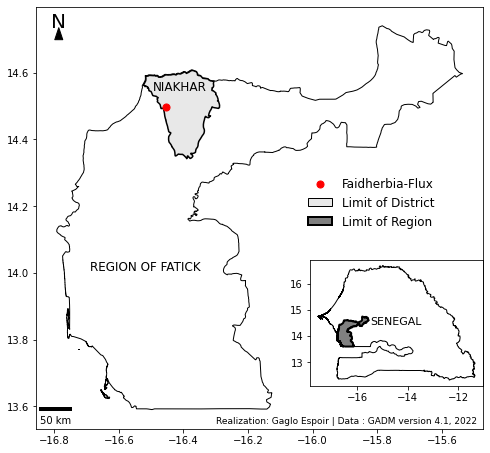

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.pyplot as plt
import contextily as ctx

# Load shapefile of Niakhar region
#https://gadm.org/download_country.html
country = gpd.read_file(r'C:/Users/AgriTech/Downloads/gadm41_SEN_shp/gadm41_SEN_0.shp')
region = gpd.read_file(r'C:/Users/AgriTech/Downloads/gadm41_SEN_shp/gadm41_SEN_1.shp')
department = gpd.read_file(r'C:/Users/AgriTech/Downloads/gadm41_SEN_shp/gadm41_SEN_2.shp')
rural_community = gpd.read_file(r'C:/Users/AgriTech/Downloads/gadm41_SEN_shp/gadm41_SEN_3.shp')
town = gpd.read_file(r'C:/Users/AgriTech/Downloads/gadm41_SEN_shp/gadm41_SEN_4.shp')

fatick = region[region['NAME_1'] == 'Fatick']

department_fatick = department[department['NAME_1'] == 'Fatick']

niakhar = rural_community[rural_community['NAME_3'] == 'Niakhar']
fig, ax3 = plt.subplots(figsize=(8, 8))

# First new axes
ax1 = fig.add_axes([0.6, 0.17, 0.3, 0.3])

#Plot country and region in same axe
country.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=1)
fatick.plot(ax=ax1, facecolor='grey', edgecolor='black', linewidth=2)

# Add country name
ax1.annotate(text=country["COUNTRY"][0].upper(), xy=country["geometry"][0].centroid.coords[0], ha='center', va='bottom', fontsize=11)
#ax1.axis('off')


#Plot region in another axe
fatick.plot(ax=ax3, facecolor='none', edgecolor='black', linewidth=1)
"""
department_fatick.plot(ax=ax3, facecolor='none', edgecolor='black', linewidth=1)
department_fatick[department_fatick['NAME_2'] == 'Fatick'].plot(ax=ax3, facecolor='#E8E8E8', edgecolor='black', linewidth=1)
for idx, row in department_fatick.iterrows():
    ax3.annotate(text=row['NAME_2'], xy=row['geometry'].centroid.coords[0], ha='center', va='top')
"""    
    
ax3.annotate(text="REGION OF " + fatick["NAME_1"][2].upper(), xy=(fatick["geometry"][2].centroid.coords[0][0], 
                                                   fatick["geometry"][2].centroid.coords[0][1]-.15), ha='right', va='baseline', fontsize=12)

#Plot region in district
niakhar.plot(ax=ax3, facecolor='#E8E8E8', edgecolor='black', linewidth=1.5, label="District limit", legend=True)

# for idx, row in niakhar.iterrows():
ax3.annotate(text=niakhar["NAME_3"][20].upper(), xy=(niakhar["geometry"][20].centroid.coords[0][0]+.07, 
                                                   niakhar["geometry"][20].centroid.coords[0][1]+.05), ha='right', va='baseline', fontsize=12)

# Add the point with location N: 14°29′44.916′′; W: 16°27′12.851′′
scatter_patch = ax3.scatter(-16.453570, 14.495810, s=50, c='red', marker='o', label='Faidherbia-Flux')
legend_handles, legend_labels = ax3.get_legend_handles_labels()


# Add north arrow

arrow_props = dict(facecolor='black', width=0.5, headwidth=8)
ax3.annotate('N', xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=20, ha='center', va='top', annotation_clip=False,
             xytext=(0, 15), textcoords='offset points',
             arrowprops=arrow_props)


# Plot the district and region limit legend
district_patch = mpatches.Patch(facecolor='#E8E8E8', edgecolor='black')
region_patch = mpatches.Patch(facecolor='grey', edgecolor='black', linewidth=2)
legend_handles.append(district_patch)
legend_labels.append("Limit of District")
legend_handles.append(region_patch)
legend_labels.append("Limit of Region")

# Add the legend to the plot
ax3.legend(handles=legend_handles, labels=legend_labels, loc='lower center', 
           frameon=False, fontsize=12, bbox_to_anchor=(.75, 0.45))
ax3.text(x=-16.3, y=13.55, s="Realization: Gaglo Espoir | Data : GADM version 4.1, 2022", fontsize=9)

# Add a scale bar to the plot in kilometers
scalebar = ScaleBar(500, 'km', length_fraction=0.1, location='lower left')
ax3.add_artist(scalebar)
plt.show()